# Exercise 1

## Exercise 1.1

write a code that prints the following pattern. Try to use as few loops as possible.

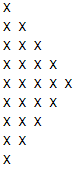

Avoid using trivial solutions like:

print('X')

print('X X')

print('X X X')

.....

print('X X X')

print('X X')

print('X')


In [ ]:
n = 5
for i in range(1, 2 * n):
    count = i if i <= n else 2 * n - i
    print(" ".join(["X"] * count))

## Exercise 1.2

Write a script that will sum all numbers in the following string. You can split each number into single digits, so for example, you can consider 45 to be 4 and 5

In [ ]:
input_str = "n45as29@#8ss6"

celkovy_soucet = sum(int(char) for char in input_str if char.isdigit())

print(f"Součet cifer je: {celkovy_soucet}")

## Exercise 1.3

Write a script that will convert an arbitrary integer to a binary number (the number will be represented as a string with only *0* and *1*). Avoid using the *bin()* function or any other pythons default functions

In [ ]:
def int_to_binary(n: int) -> str:
    if n == 0:
        return "0"

    is_negative = n < 0
    n = abs(n)
    binary_str = ""

    while n > 0:
        binary_str = str(n % 2) + binary_str
        n = n // 2

    return "-" + binary_str if is_negative else binary_str

print(int_to_binary(45))

## Exercise 1.4 - The Fibonacci Sequence:

The Fibonacci Sequence is a series of numbers. The following number is found by adding up the two numbers before it. The first two numbers are 0 and 1. For example, 0, 1, 1, 2, 3, 5, 8, 13. The following number in this series above is 8 + 13 = 21


Your task is to implement a function *fibonacci* that takes an integer as an input and returns a list that contains all Fibonacci numbers with values lower than the input integer

Example:

*print(fibonaci(10))*

[0, 1, 1, 2, 3, 5, 8]


In [ ]:
def fibonacci(upper_threshold: int) -> list:
    if upper_threshold <= 0:
        return []
    if upper_threshold == 1:
        return [0]

    fib_list = [0, 1]

    while True:
        next_fib = fib_list[-1] + fib_list[-2]
        if next_fib >= upper_threshold:
            break
        fib_list.append(next_fib)

    return fib_list

print(fibonacci(10))

#### Advanced

Try to implement the function using multiple approaches: *Iterative approach*, *Recusrion*, *Memoization*

## Exercise 1.5. -  Rock, Paper, Scissors game:

#### basic

*Rock, Paper, Scissors* is a well-known and straightforward game. If you do not know the rules, google them. We will write a code for the Rock, Paper, Scissors game where the user plays against a random computer. The code can be written into one function *rock_paper_scissors*.

Notes:
- This implementation uses the **random** library to enable the computer to make a random choice.
- Keyword **Input** may be helpful. Check it
- After the function is run, the program will ask you about your movement, which you type in
- The game is case-insensitive for user input (e.g., "rock", "Rock", and "ROCK" are all valid).
- This script plays one round of the game.
- The script prints the result ('You lose', 'You win', 'It is a tie')


In [ ]:
import random

def rock_paper_scissors(n_rounds: int = 3) -> None:
    choices = ['kámen', 'papír', 'nůžky']
    user_score = 0
    comp_score = 0

    for round_num in range(1, n_rounds + 1):
        print(f"\n--- Kolo {round_num} ---")
        user_choice = input("Zadej kámen, papír, nebo nůžky: ").lower()

        while user_choice not in choices:
            user_choice = input("Špatný vstup. Zadej kámen, papír, nebo nůžky: ").lower()

        comp_choice = random.choice(choices)
        print(f"Počítač zvolil: {comp_choice}")

        if user_choice == comp_choice:
            print("remíza")
        elif (user_choice == 'kámen' and comp_choice == 'nůžky') or \
             (user_choice == 'papír' and comp_choice == 'kámen') or \
             (user_choice == 'nůžky' and comp_choice == 'papír'):
            print("Vyhrál jsi")
            user_score += 1
        else:
            print("Prohrál jsi")
            comp_score += 1

        print(f"Průběžné skóre -> Hráč: {user_score} | Počítač: {comp_score}")

    print("\n=== KONEČNÝ VÝSLEDEK ===")
    if user_score > comp_score:
        print("Vyhrál jsi!")
    elif user_score < comp_score:
        print("Prohrál jsi!")
    else:
        print("remíza")

rock_paper_scissors(3)

#### Advanced

Extend the Rock, Paper, Scissors game to be able to play *n* rounds.

Notes:
- The scrips will contain two counters - user score and computer score
- After each run, the script prints the current scores and rounds.
- When the number of rounds is reached, the script prints the result ('You lose', 'You win', 'It is a tie')

# Exercise 2

The purpose of this excercise is to practise working with NumPy library

## Exercise 2.1


In this exercise, you will work with NumPy arrays and learn how to efficiently modify and process them using both loops and vectorized operations. Your task is to:

1. Implement the function *create_array_nxn* that generates an n×n NumPy array filled with numbers from n² - 1 down to 0
2. Using a loop-based approach (for-loop, while-loop), implement the function *apply_threshold_loop* that takes any NumPy array and replaces all numbers below a user-defined threshold with 0.
3. Implement function *apply_threshold_vectorized* that performs the same operation as *apply_threshold_loop*, but without loops, using NumPy vectorized operations
4. Implement function *compare_performance* that compares the execution time of functions *apply_threshold_vectorized* and *apply_threshold_loop* with **time** library and print the results


**Additional Notes**:

- Ensure n is a positive integer (n > 0).
- Use the time library to measure execution times for performance comparison.
- The function *compare_performance(n, threshold)* should:
    - Generate an n×n array.
    - Apply both loop-based and vectorized thresholding.
    - Print execution times.

In [ ]:
import numpy as np
import time

def create_array_nxn(n: int) -> np.ndarray:
    return np.arange(n**2 - 1, -1, -1).reshape((n, n))

def apply_threshold_loop(arr: np.ndarray, threshold: int) -> np.ndarray:
    result = arr.copy()
    rows, cols = result.shape
    for i in range(rows):
        for j in range(cols):
            if result[i, j] < threshold:
                result[i, j] = 0
    return result

def apply_threshold_vectorized(arr: np.ndarray, threshold: int) -> np.ndarray:
    result = arr.copy()
    result[result < threshold] = 0
    return result

def compare_performance(n: int, threshold: int) -> None:
    arr = create_array_nxn(n)

    start_time = time.time()
    apply_threshold_loop(arr, threshold)
    loop_time = time.time() - start_time

    start_time = time.time()
    apply_threshold_vectorized(arr, threshold)
    vectorized_time = time.time() - start_time

    print(f"Čas přes cykly: {loop_time:.6f} sekund")
    print(f"Čas vektorizovaně: {vectorized_time:.6f} sekund")

compare_performance(1000, 50000)

## Exercise 2.2 - Digi display

#### basic

The task will be to create a simulation of a Digi display that will be able to display an arbitrary integer
   
*hint: to show the image, use the library matplotlib.pyplot. Also, you may find function *np.concatenate* helpful

show_in_digi(5289) will show:


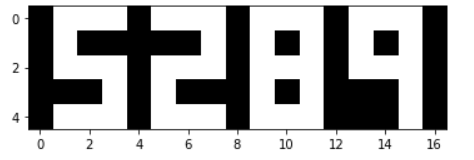

*hint2: you may find the following dict usefull*

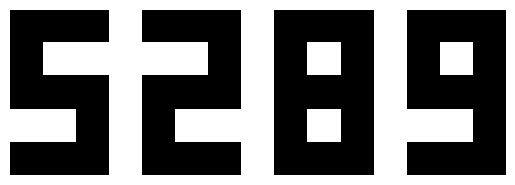

In [34]:
import matplotlib.pyplot as plt

def show_in_digi(input_integer: int) -> None:
    digits = {
        '0': [[1,1,1],[1,0,1],[1,0,1],[1,0,1],[1,1,1]],
        '1': [[0,0,1],[0,0,1],[0,0,1],[0,0,1],[0,0,1]],
        '2': [[1,1,1],[0,0,1],[1,1,1],[1,0,0],[1,1,1]],
        '3': [[1,1,1],[0,0,1],[1,1,1],[0,0,1],[1,1,1]],
        '4': [[1,0,1],[1,0,1],[1,1,1],[0,0,1],[0,0,1]],
        '5': [[1,1,1],[1,0,0],[1,1,1],[0,0,1],[1,1,1]],
        '6': [[1,1,1],[1,0,0],[1,1,1],[1,0,1],[1,1,1]],
        '7': [[1,1,1],[0,0,1],[0,0,1],[0,0,1],[0,0,1]],
        '8': [[1,1,1],[1,0,1],[1,1,1],[1,0,1],[1,1,1]],
        '9': [[1,1,1],[1,0,1],[1,1,1],[0,0,1],[1,1,1]]
    }

    spacer = np.zeros((5, 1))

    display_list = []
    num_str = str(input_integer)

    for i, char in enumerate(num_str):
        display_list.append(np.array(digits[char]))
        if i < len(num_str) - 1:
            display_list.append(spacer)

    final_image = np.concatenate(display_list, axis=1)

    plt.imshow(final_image, cmap='Greys')
    plt.axis('off')
    plt.show()

show_in_digi(5289)

#### advanced

Extend your *show_in_digi* function to be able to display an arbitary float number and negative numbers

# Exercise 3 - Playing with California Housing Dataset

The purpose of this exercise is to learn basic operations of **pandas** library. Use *california_housing_dataset* you can find in google colab to do following operations:

- check what *dataset.describe()* does

- display all rows where *total_bedrooms* column is bigger than 310

- drop also first and last row

- save a mean of values in *households* columns to variable, using *matplotlib* display number of households in the graph (x-axis would be ID, y-axis - numbers of households) as dots with the same color, display also mean as a single line in the graph with different color as dots is

 - check if any of the columns contain NaN values, if yes, replace the NaN values with the arithmetic mean of the whole dataset

 - display *lat* and *long* into plot, *lat* would be on *x* axis and *long* on *y* axis

- choose two arbitrary columns and normalize all values inside using *min-max normalization*:

- Create a Correlation Matrix from all columns

--- 1. Základní statistiky (describe) ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000



--- 2. Záznamy, kde total_bedrooms > 310 ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
7,-120.65,35.48,19.0,2310.0,471.0,1341.0,441.0,3.2250,166900.0
8,-122.84,38.40,15.0,3080.0,617.0,1446.0,599.0,3.6696,194400.0
9,-118.02,34.08,31.0,2402.0,632.0,2830.0,603.0,2.3333,164200.0
...,...,...,...,...,...,...,...,...,...
2990,-118.23,34.09,49.0,1638.0,456.0,1500.0,430.0,2.6923,150000.0
2991,-117.17,34.28,13.0,4867.0,718.0,780.0,250.0,7.1997,253800.0
2993,-117.91,33.60,37.0,2088.0,510.0,673.0,390.0,5.1048,500001.0
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0



--- 3. Dataset po zahození prvního a posledního řádku ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
5,-119.56,36.51,37.0,1018.0,213.0,663.0,204.0,1.6635,67000.0


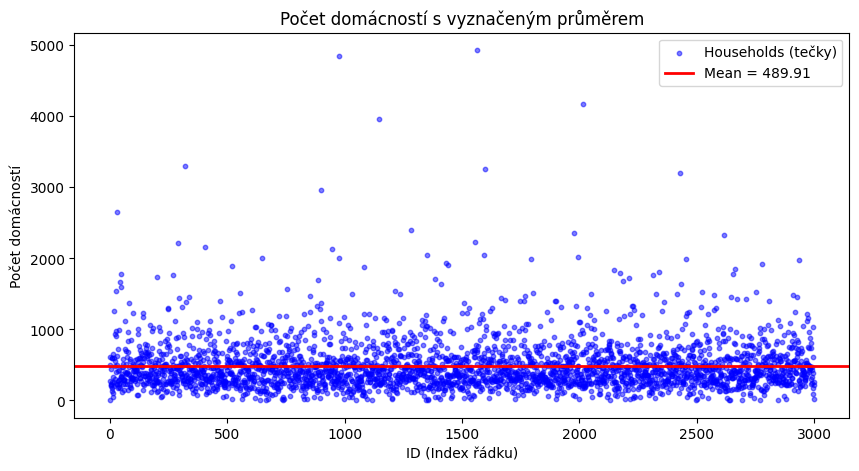


--- 5. Kontrola a nahrazení NaN hodnot ---
Jsou v datasetu NaN hodnoty před úpravou? -> False
Jsou v datasetu NaN hodnoty po úpravě? -> False


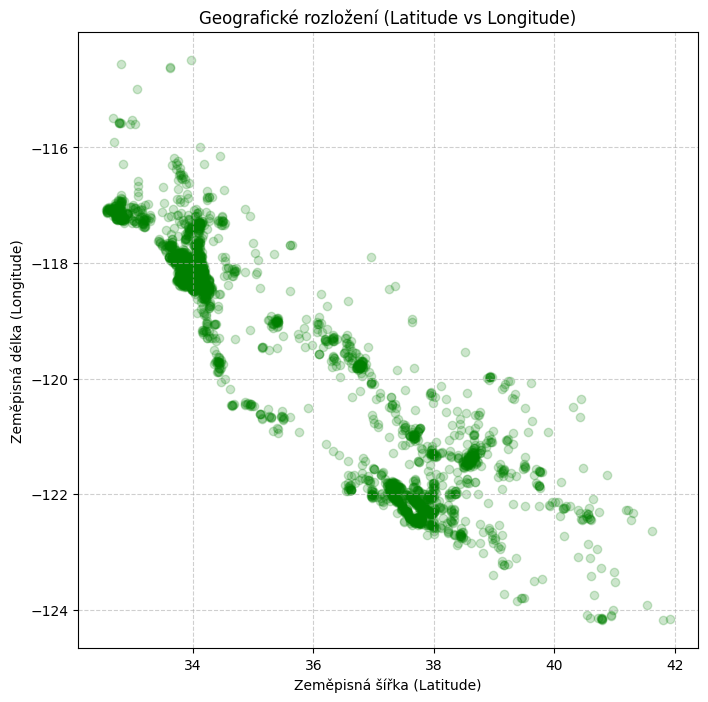


--- 7. Min-Max normalizace ---
Statistiky po normalizaci (min by mělo být 0 a max 1):


,median_income,housing_median_age
count,3000.000000,3000.000000
mean,0.228091,0.545987
std,0.127896,0.246184
min,0.000000,0.000000
25%,0.140970,0.333333
50%,0.206014,0.549020
75%,0.286656,0.705882
max,1.000000,1.000000



--- 8. Korelační matice ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.925017,-0.064203,0.049865,0.070869,0.111572,0.051062,-0.018701,-0.050662
latitude,-0.925017,1.000000,-0.025143,-0.039632,-0.068245,-0.117318,-0.068296,-0.072363,-0.138428
housing_median_age,-0.064203,-0.025143,1.000000,-0.367850,-0.323154,-0.299888,-0.305171,-0.144315,0.091409
total_rooms,0.049865,-0.039632,-0.367850,1.000000,0.937749,0.838867,0.914116,0.221249,0.160427
total_bedrooms,0.070869,-0.068245,-0.323154,0.937749,1.000000,0.856387,0.970758,0.024025,0.082279
population,0.111572,-0.117318,-0.299888,0.838867,0.856387,1.000000,0.895530,0.032361,-0.001192
households,0.051062,-0.068296,-0.305171,0.914116,0.970758,0.895530,1.000000,0.048625,0.100176
median_income,-0.018701,-0.072363,-0.144315,0.221249,0.024025,0.032361,0.048625,1.000000,0.672695
median_house_value,-0.050662,-0.138428,0.091409,0.160427,0.082279,-0.001192,0.100176,0.672695,1.000000


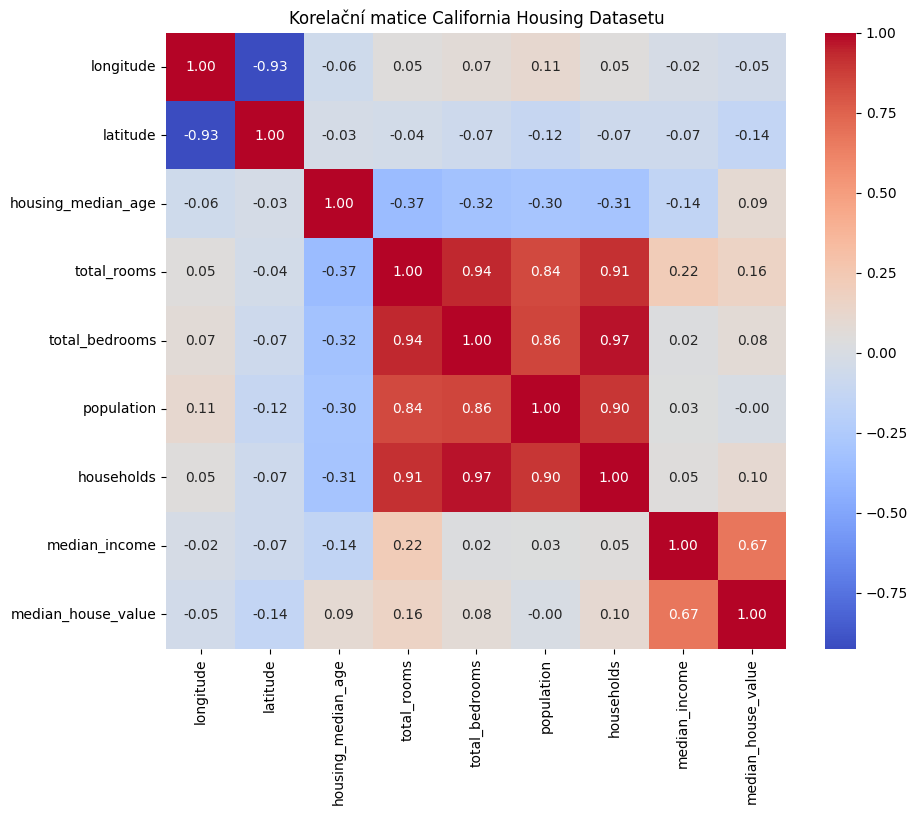

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

dataset = pd.read_csv('sample_data/california_housing_test.csv')

print("--- 1. Základní statistiky (describe) ---")
display(dataset.describe())

print("\n--- 2. Záznamy, kde total_bedrooms > 310 ---")
bedrooms_filtered = dataset[dataset['total_bedrooms'] > 310]
display(bedrooms_filtered)

print("\n--- 3. Dataset po zahození prvního a posledního řádku ---")
dataset_dropped = dataset.iloc[1:-1]
display(dataset_dropped.head())

mean_households = dataset['households'].mean()

plt.figure(figsize=(10, 5))
plt.scatter(dataset.index, dataset['households'], color='blue', s=10, label='Households (tečky)', alpha=0.5)
plt.axhline(y=mean_households, color='red', linestyle='-', linewidth=2, label=f'Mean = {mean_households:.2f}')
plt.title('Počet domácností s vyznačeným průměrem')
plt.xlabel('ID (Index řádku)')
plt.ylabel('Počet domácností')
plt.legend()
plt.show()

print("\n--- 5. Kontrola a nahrazení NaN hodnot ---")
print("Jsou v datasetu NaN hodnoty před úpravou? ->", dataset.isna().any().any())

dataset = dataset.fillna(dataset.mean())

print("Jsou v datasetu NaN hodnoty po úpravě? ->", dataset.isna().any().any())

plt.figure(figsize=(8, 8))
plt.scatter(dataset['latitude'], dataset['longitude'], alpha=0.2, color='green')
plt.title('Geografické rozložení (Latitude vs Longitude)')
plt.xlabel('Zeměpisná šířka (Latitude)')
plt.ylabel('Zeměpisná délka (Longitude)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n--- 7. Min-Max normalizace ---")
cols_to_normalize = ['median_income', 'housing_median_age']

for col in cols_to_normalize:
    col_min = dataset[col].min()
    col_max = dataset[col].max()
    dataset[col] = (dataset[col] - col_min) / (col_max - col_min)

print("Statistiky po normalizaci (min by mělo být 0 a max 1):")
display(dataset[cols_to_normalize].describe())

print("\n--- 8. Korelační matice ---")
corr_matrix = dataset.corr()
display(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelační matice California Housing Datasetu')
plt.show()